In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load Daily Returns dataset
daily_returns = pd.read_csv("../data/processed/daily_returns.csv")

# Display dataset shape
print("Shape:", daily_returns.shape)

# Display first 5 rows
daily_returns.head()

Shape: (45960, 4)


,amfi_code,date,nav,daily_return
0,100016,2022-01-04,515.0971,-0.010306
1,100016,2022-01-05,521.7239,0.012865
2,100016,2022-01-06,515.7880,-0.011377
3,100016,2022-01-07,515.1639,-0.001210
4,100016,2022-01-10,510.7136,-0.008639


In [4]:
# Check data information
daily_returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45960 entries, 0 to 45959
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   amfi_code     45960 non-null  int64  
 1   date          45960 non-null  object 
 2   nav           45960 non-null  float64
 3   daily_return  45960 non-null  float64
dtypes: float64(2), int64(1), object(1)
memory usage: 1.4+ MB


In [5]:
# Summary statistics
daily_returns.describe()

,amfi_code,nav,daily_return
count,45960.000000,45960.000000,45960.000000
mean,120247.000000,269.624535,0.000631
std,14352.317357,577.252241,0.010290
min,100016.000000,26.136600,-0.058102
25%,118632.750000,69.195975,-0.005042
50%,119551.500000,122.802200,0.000340
75%,120842.250000,260.426750,0.006324
max,149324.000000,4268.549700,0.064713


In [6]:
# Load cleaned NAV history
nav_df = pd.read_csv("../data/processed/nav_history_cleaned.csv")

# Convert date column
nav_df["date"] = pd.to_datetime(nav_df["date"])

# Sort values
nav_df = nav_df.sort_values(["amfi_code", "date"])

print("Shape:", nav_df.shape)
nav_df.head()

Shape: (46000, 3)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [7]:
# Calculate CAGR for each fund

results = []

for code, group in nav_df.groupby("amfi_code"):
    group = group.sort_values("date")

    start_nav = group.iloc[0]["nav"]
    end_nav = group.iloc[-1]["nav"]

    years = (group.iloc[-1]["date"] - group.iloc[0]["date"]).days / 365.25

    if years > 0:
        cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100
    else:
        cagr = None

    results.append({
        "amfi_code": code,
        "start_nav": start_nav,
        "end_nav": end_nav,
        "years": round(years, 2),
        "CAGR (%)": round(cagr, 2)
    })

cagr_df = pd.DataFrame(results)

cagr_df.head()

,amfi_code,start_nav,end_nav,years,CAGR (%)
0,100016,520.4608,583.6113,4.4,2.64
1,100025,26.3169,31.8843,4.4,4.46
2,100033,107.3758,342.0072,4.4,30.12
3,101206,305.0996,773.2939,4.4,23.54
4,101207,38.5736,53.9836,4.4,7.94


In [8]:
# Save CAGR data
cagr_df.to_csv("../data/processed/cagr.csv", index=False)

print("CAGR calculation completed successfully!")
print("Output file: data/processed/cagr.csv")

CAGR calculation completed successfully!
Output file: data/processed/cagr.csv


In [9]:
# Annual Risk-Free Rate
risk_free_rate = 0.065

# Convert to daily risk-free rate
daily_rf = risk_free_rate / 252

# Calculate Sharpe Ratio
sharpe_results = []

for code, group in daily_returns.groupby("amfi_code"):

    mean_return = group["daily_return"].mean()
    std_return = group["daily_return"].std()

    if std_return != 0:
        sharpe = ((mean_return - daily_rf) / std_return) * np.sqrt(252)
    else:
        sharpe = np.nan

    sharpe_results.append({
        "amfi_code": code,
        "average_daily_return": round(mean_return, 6),
        "std_deviation": round(std_return, 6),
        "sharpe_ratio": round(sharpe, 4)
    })

sharpe_df = pd.DataFrame(sharpe_results)

sharpe_df.head()

,amfi_code,average_daily_return,std_deviation,sharpe_ratio
0,100016,0.000142,0.009164,-0.2015
1,100025,0.000170,0.002460,-0.5671
2,100033,0.001080,0.011929,1.0937
3,101206,0.000852,0.009177,1.0272
4,101207,0.000424,0.016251,0.1627


In [10]:
# Rank funds by Sharpe Ratio
sharpe_df = sharpe_df.sort_values(
    by="sharpe_ratio",
    ascending=False
)

sharpe_df["Rank"] = range(1, len(sharpe_df) + 1)

sharpe_df.head(10)

,amfi_code,average_daily_return,std_deviation,sharpe_ratio,Rank
34,148567,0.001074,0.008941,1.4483,1
30,120843,0.001082,0.010008,1.3067,2
36,148569,0.001124,0.011134,1.2349,3
19,119551,0.000917,0.008656,1.2083,4
25,120505,0.001161,0.012152,1.1801,5
38,149323,0.001055,0.011179,1.1321,6
2,100033,0.001080,0.011929,1.0937,7
9,118632,0.000865,0.008913,1.0817,8
3,101206,0.000852,0.009177,1.0272,9
24,120504,0.000843,0.009048,1.0265,10


In [11]:
# Save Sharpe Ratio results
sharpe_df.to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio calculation completed successfully!")
print("Output saved to: data/processed/sharpe_ratio.csv")

Sharpe Ratio calculation completed successfully!
Output saved to: data/processed/sharpe_ratio.csv


In [12]:
# Calculate Sortino Ratio

sortino_results = []

for code, group in daily_returns.groupby("amfi_code"):

    mean_return = group["daily_return"].mean()

    # Downside returns only
    downside_returns = group[group["daily_return"] < 0]["daily_return"]

    downside_std = downside_returns.std()

    if pd.notna(downside_std) and downside_std != 0:
        sortino = ((mean_return - daily_rf) / downside_std) * np.sqrt(252)
    else:
        sortino = np.nan

    sortino_results.append({
        "amfi_code": code,
        "average_daily_return": round(mean_return, 6),
        "downside_std": round(downside_std, 6) if pd.notna(downside_std) else np.nan,
        "sortino_ratio": round(sortino, 4) if pd.notna(sortino) else np.nan
    })

sortino_df = pd.DataFrame(sortino_results)

sortino_df.head()

,amfi_code,average_daily_return,downside_std,sortino_ratio
0,100016,0.000142,0.005261,-0.3510
1,100025,0.000170,0.001481,-0.9418
2,100033,0.001080,0.007133,1.8291
3,101206,0.000852,0.005238,1.7996
4,101207,0.000424,0.009555,0.2766


In [13]:
# Rank by Sortino Ratio

sortino_df = sortino_df.sort_values(
    by="sortino_ratio",
    ascending=False
)

sortino_df["Rank"] = range(1, len(sortino_df) + 1)

sortino_df.head(10)

,amfi_code,average_daily_return,downside_std,sortino_ratio,Rank
34,148567,0.001074,0.005428,2.3856,1
30,120843,0.001082,0.005531,2.3643,2
36,148569,0.001124,0.006404,2.1469,3
19,119551,0.000917,0.004887,2.1403,4
25,120505,0.001161,0.007067,2.0294,5
38,149323,0.001055,0.006750,1.8751,6
9,118632,0.000865,0.005211,1.8501,7
2,100033,0.001080,0.007133,1.8291,8
24,120504,0.000843,0.005145,1.8053,9
3,101206,0.000852,0.005238,1.7996,10


In [14]:
# Save Sortino Ratio

sortino_df.to_csv(
    "../data/processed/sortino_ratio.csv",
    index=False
)

print("Sortino Ratio calculation completed successfully!")
print("Output saved to: data/processed/sortino_ratio.csv")

Sortino Ratio calculation completed successfully!
Output saved to: data/processed/sortino_ratio.csv


In [16]:
# Load Benchmark Data
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

# Convert date (YYYY-MM-DD)
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Sort by date
benchmark = benchmark.sort_values("date")

# Calculate benchmark daily return
benchmark["benchmark_return"] = benchmark["close_value"].pct_change()

# Remove first NaN row
benchmark = benchmark.dropna()

benchmark.head()

,date,index_name,close_value,benchmark_return
5750,2022-01-03,CRISIL_LIQUID,2281.51,-0.869574
2300,2022-01-03,NIFTY_MIDCAP150,9721.79,3.261121
6900,2022-01-03,CRISIL_GILT,1451.06,-0.850741
1150,2022-01-03,NIFTY100,17778.24,11.251899
4600,2022-01-03,NIFTY500,14837.07,-0.165437


In [22]:
# Convert both date columns to datetime

daily_returns["date"] = pd.to_datetime(daily_returns["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

print(daily_returns["date"].dtype)
print(benchmark["date"].dtype)

datetime64[ns]
datetime64[ns]


In [23]:
# Calculate Alpha & Beta

alpha_beta_results = []

for code, group in daily_returns.groupby("amfi_code"):

    merged = pd.merge(
        group,
        benchmark[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    if len(merged) > 20:

        slope, intercept, r_value, p_value, std_err = stats.linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha_beta_results.append({
            "amfi_code": code,
            "alpha": round(intercept * 252, 6),
            "beta": round(slope, 4),
            "r_squared": round(r_value ** 2, 4)
        })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

print("Rows:", len(alpha_beta_df))
alpha_beta_df.head()

Rows: 40


,amfi_code,alpha,beta,r_squared
0,100016,0.037661,-0.0,0.0
1,100025,0.044818,-0.0,0.0
2,100033,0.265138,0.0,0.0
3,101206,0.208464,0.0,0.0
4,101207,0.109861,-0.0,0.0


In [24]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("Alpha & Beta saved successfully!")

Alpha & Beta saved successfully!


In [17]:
# Calculate Maximum Drawdown

drawdown_results = []

for code, group in nav_df.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    # Running maximum NAV
    group["running_max"] = group["nav"].cummax()

    # Drawdown
    group["drawdown"] = (
        (group["nav"] - group["running_max"])
        / group["running_max"]
    )

    # Maximum drawdown
    max_dd = group["drawdown"].min()

    # Date of maximum drawdown
    max_dd_date = group.loc[
        group["drawdown"].idxmin(),
        "date"
    ]

    drawdown_results.append({
        "amfi_code": code,
        "maximum_drawdown": round(max_dd * 100, 2),
        "worst_date": max_dd_date
    })

drawdown_df = pd.DataFrame(drawdown_results)

drawdown_df.head()

,amfi_code,maximum_drawdown,worst_date
0,100016,-24.73,2022-09-15
1,100025,-4.31,2023-07-28
2,100033,-16.22,2022-05-12
3,101206,-11.29,2023-07-05
4,101207,-35.45,2026-05-11


In [18]:
# Save Maximum Drawdown

drawdown_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

print("Maximum Drawdown calculation completed successfully!")
print("Output saved to: data/processed/max_drawdown.csv")

Maximum Drawdown calculation completed successfully!
Output saved to: data/processed/max_drawdown.csv


In [25]:
# Load required datasets

performance = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")
sharpe = pd.read_csv("../data/processed/sharpe_ratio.csv")
alpha = pd.read_csv("../data/processed/alpha_beta.csv")
drawdown = pd.read_csv("../data/processed/max_drawdown.csv")

# Merge all datasets
score_df = performance.merge(sharpe, on="amfi_code")
score_df = score_df.merge(alpha, on="amfi_code")
score_df = score_df.merge(drawdown, on="amfi_code")

score_df.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha_x,beta_x,sharpe_ratio_x,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,average_daily_return,std_deviation,sharpe_ratio_y,Rank,alpha_y,beta_y,r_squared,maximum_drawdown,worst_date
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,0.000917,0.008656,1.2083,4,0.222142,0.0,0.0001,-15.01,2024-02-05
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,0.000785,0.008781,0.9533,12,0.191841,0.0,0.0000,-11.80,2024-09-02
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,0.001201,0.015837,0.9453,14,0.295143,0.0,0.0000,-28.71,2025-05-14
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,0.000201,0.015717,-0.0572,32,0.051459,-0.0,0.0000,-52.57,2025-10-28
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,0.000222,0.002499,-0.2266,37,0.056697,-0.0,0.0000,-4.33,2025-04-01


In [30]:
# Higher is better
score_df["return_rank"] = score_df["return_3yr_pct"].rank(ascending=False)

score_df["sharpe_rank"] = score_df["sharpe_ratio_y"].rank(ascending=False)

score_df["alpha_rank"] = score_df["alpha_y"].rank(ascending=False)

# Lower expense ratio is better
score_df["expense_rank"] = score_df["expense_ratio_pct"].rank(ascending=True)

# Smaller drawdown is better
score_df["drawdown_rank"] = score_df["maximum_drawdown"].rank(ascending=False)

score_df.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha_x,beta_x,sharpe_ratio_x,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,average_daily_return,std_deviation,sharpe_ratio_y,Rank,alpha_y,beta_y,r_squared,maximum_drawdown,worst_date,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,0.000917,0.008656,1.2083,4,0.222142,0.0,0.0001,-15.01,2024-02-05,26.0,4.0,10.0,30.5,17.0
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,0.000785,0.008781,0.9533,12,0.191841,0.0,0.0000,-11.80,2024-09-02,34.0,12.0,15.0,4.0,11.0
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,0.001201,0.015837,0.9453,14,0.295143,0.0,0.0000,-28.71,2025-05-14,1.0,14.0,3.0,21.0,36.0
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,0.000201,0.015717,-0.0572,32,0.051459,-0.0,0.0000,-52.57,2025-10-28,2.0,32.0,36.0,5.5,40.0
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,0.000222,0.002499,-0.2266,37,0.056697,-0.0,0.0000,-4.33,2025-04-01,38.0,37.0,35.0,9.0,5.0


In [31]:
score_df["fund_score"] = (
    (41 - score_df["return_rank"]) * 0.30 +
    (41 - score_df["sharpe_rank"]) * 0.25 +
    (41 - score_df["alpha_rank"]) * 0.20 +
    (41 - score_df["expense_rank"]) * 0.15 +
    (41 - score_df["drawdown_rank"]) * 0.10
)

# Convert to 0-100 scale
score_df["fund_score"] = (
    score_df["fund_score"] /
    score_df["fund_score"].max()
) * 100

score_df = score_df.sort_values(
    by="fund_score",
    ascending=False
)

score_df[[
    "amfi_code",
    "scheme_name",
    "fund_score"
]].head(10)

,amfi_code,scheme_name,fund_score
12,120505,ICICI Pru Midcap Fund - Regular - Growth,100.000000
22,120843,Kotak Flexicap Fund - Regular - Growth,98.734177
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,96.835443
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,96.518987
2,119598,SBI Small Cap Fund - Regular Plan - Growth,94.462025
39,149324,DSP Small Cap Fund - Regular - Growth,88.844937
38,149323,DSP Midcap Fund - Regular - Growth,86.392405
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,84.493671
26,119094,Axis Midcap Fund - Regular - Growth,84.177215
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,80.300633


In [32]:
score_df.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard Created Successfully!")

Fund Scorecard Created Successfully!


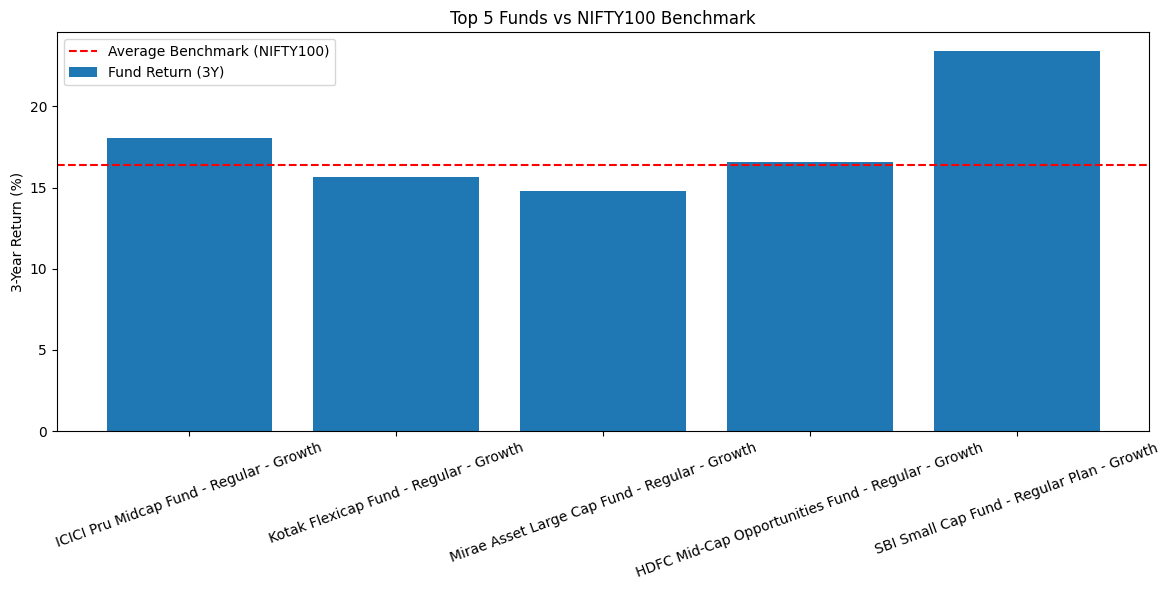

Benchmark chart saved successfully!


In [33]:
import matplotlib.pyplot as plt

# Top 5 funds based on Fund Score
top5 = score_df.head(5)

plt.figure(figsize=(12,6))

# Plot top 5 fund 3Y returns
plt.bar(
    top5["scheme_name"],
    top5["return_3yr_pct"],
    label="Fund Return (3Y)"
)

# Plot benchmark line
plt.axhline(
    y=top5["benchmark_3yr_pct"].mean(),
    color="red",
    linestyle="--",
    label="Average Benchmark (NIFTY100)"
)

plt.xticks(rotation=20)
plt.ylabel("3-Year Return (%)")
plt.title("Top 5 Funds vs NIFTY100 Benchmark")
plt.legend()

plt.tight_layout()

plt.savefig("../reports/benchmark_comparison.png")

plt.show()

print("Benchmark chart saved successfully!")